# Domain architecture by function — Pfam atlas on Ensembl r115

This notebook builds the manuscript's functional-architecture analyses directly
from a current annotation (Ensembl release 115), so every number is reproducible
end to end:

1. **Exons per domain, by function** — what fraction of each functional class is
   encoded by a single exon (Fig. 1D).
2. **Position of the domain in the transcript** — where domains sit along the
   5′→3′ exon order.
3. **Completeness** — what fraction of the nucleotides of the exons a domain
   touches actually code that domain.

Every Pfam-A instance on the **canonical isoform of each gene** is mapped with
`prot2exon`, and the per-domain exon structure is summarised (we pull all
isoforms from BioMart, then keep one representative per gene so a domain is not
counted once per splice variant). The heavy steps are **cache-aware**:
if the prepared file is already on disk they are skipped, so a re-run is fast.

### Inputs (all prepared below if missing)

| File | Source |
|---|---|
| `pfam_human_v115_meta.tsv` / `.bed` | Ensembl BioMart (release 115): ENSP + Pfam accession + aa range |
| `human_v115.idx` | `prot2exon index` on the release-115 GTF |
| `pfam2go.txt` | GO `external2go/pfam2go` — Pfam → GO, used for functional class |

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, subprocess, pickle, re, urllib.parse, urllib.request, time
from pathlib import Path
import pandas as pd
import numpy as np
import prot2exon as p2e

DATA = Path.home() / "Desktop" / "protein2genomic_data"
BIN  = None  # let the wrapper auto-discover the binary

META  = DATA / "pfam_human_v115_meta.tsv"
PBED  = DATA / "pfam_human_v115.bed"
IDX   = DATA / "human_v115.idx"
ATLAS = DATA / "atlas_v115"        # prot2exon coding output
P2GO  = DATA / "pfam2go.txt"
print("data dir:", DATA)

data dir: /home/goguxor/Desktop/protein2genomic_data


## 1. Pfam-A domains from Ensembl BioMart (release 115)

We pull every Pfam-A instance on the human proteome — one row per
`(ENSP, Pfam accession, aa_start, aa_end)` — straight from the current Ensembl
BioMart. (Skipped if the table is already prepared.)

In [2]:
def pull_biomart_pfam(meta_path, bed_path):
    host = "https://www.ensembl.org/biomart/martservice"
    chroms = [str(i) for i in range(1, 23)] + ["X", "Y", "MT"]
    def xml(c):
        return ('<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query>'
            '<Query virtualSchemaName="default" formatter="TSV" header="0" '
            'uniqueRows="1" count="" datasetConfigVersion="0.6">'
            '<Dataset name="hsapiens_gene_ensembl" interface="default">'
            f'<Filter name="chromosome_name" value="{c}"/>'
            '<Attribute name="ensembl_peptide_id"/><Attribute name="pfam"/>'
            '<Attribute name="pfam_start"/><Attribute name="pfam_end"/>'
            '</Dataset></Query>')
    seen, rows = set(), []
    for c in chroms:
        url = host + "?" + urllib.parse.urlencode({"query": xml(c)})
        with urllib.request.urlopen(url, timeout=180) as r:
            txt = r.read().decode()
        for ln in txt.splitlines():
            f = ln.split("\t")
            if len(f) != 4 or not f[0] or not f[1].startswith("PF"):
                continue
            pid, pf, s, e = f
            if not s or not e or (pid, pf, s, e) in seen:
                continue
            seen.add((pid, pf, s, e)); rows.append((pid, pf, int(s), int(e)))
    rows.sort(key=lambda r: (r[0], r[2]))
    with open(bed_path, "w") as bed, open(meta_path, "w") as mt:
        mt.write("query_id\tprotein_id\tpfam_id\taa_start\taa_end\n")
        for i, (pid, pf, s, e) in enumerate(rows):
            if s < 1 or e < s:
                continue
            q = f"PFAM{i:07d}"
            bed.write(f"{pid}\t{s}\t{e}\t{q}\n")
            mt.write(f"{q}\t{pid}\t{pf}\t{s}\t{e}\n")
    return len(rows)

if META.exists() and PBED.exists():
    print("(cached) Pfam BED already prepared")
else:
    n = pull_biomart_pfam(META, PBED)
    print(f"pulled {n:,} Pfam-A instances from BioMart")

meta = pd.read_csv(META, sep="\t")
print(f"{len(meta):,} Pfam-A instances across {meta.protein_id.nunique():,} proteins")

(cached) Pfam BED already prepared


472,856 Pfam-A instances across 190,186 proteins


## 2. Index the release-115 GTF and map every domain

`prot2exon index` compiles the GTF once; `prot2exon map --output coding` then
projects all ~470 K domains onto their CDS exons in well under a minute. Both
steps are cached.

In [3]:
import gzip, shutil, urllib.request
GTF_URL = ("https://ftp.ensembl.org/pub/release-115/gtf/homo_sapiens/"
           "Homo_sapiens.GRCh38.115.gtf.gz")
if not IDX.exists():
    gtf = DATA / "Homo_sapiens.GRCh38.115.gtf"
    if not gtf.exists():                       # download + gunzip the GTF (~100 MB gz)
        gz = DATA / "Homo_sapiens.GRCh38.115.gtf.gz"
        if not gz.exists():
            print("downloading release-115 GTF ...")
            urllib.request.urlretrieve(GTF_URL, gz)
        with gzip.open(gz, "rb") as fi, open(gtf, "wb") as fo:
            shutil.copyfileobj(fi, fo)
    print("building index (~15 s) ...")
    p2e.build_index(str(gtf), out=str(IDX))

if (ATLAS / "domain_cds_segments.tsv").exists():
    print("(cached) atlas already mapped")
else:
    mapper = p2e.Mapper(index=str(IDX), threads=os.cpu_count() or 1,
                        batch_size=20000)
    bed = pd.read_csv(PBED, sep="\t", header=None,
                      names=["protein_id", "aa_start", "aa_end", "domain_id"])
    mapper.map_batch(bed, output="coding", keep_outputs=str(ATLAS))
print("CDS segment table:", ATLAS / "domain_cds_segments.tsv")

(cached) atlas already mapped
CDS segment table: /home/goguxor/Desktop/protein2genomic_data/atlas_v115/domain_cds_segments.tsv


## 3. Functional classification (pfam2go)

Each Pfam family is assigned a broad functional class from its Gene Ontology
annotation (`pfam2go`). The DNA-binding class here is the **broad GO net**:
any family annotated with a *DNA binding* GO term. This is automatic and
unbiased — it also sweeps in DNA-acting enzymes (helicases, polymerases), which
is why it is more conservative than a hand-curated transcription-factor DBD set
(that curated comparison is in the supplement).

In [4]:
if not P2GO.exists():
    urllib.request.urlretrieve(
        "https://current.geneontology.org/ontology/external2go/pfam2go", P2GO)

pf2go = {}
for ln in open(P2GO):
    if not ln.startswith("Pfam:"):
        continue
    m = re.match(r"Pfam:(PF\d+)\s+\S+ > GO:(.+?) ; GO:\d+", ln.strip())
    if m:
        pf2go.setdefault(m.group(1), set()).add(m.group(2).lower())

ENZYME = re.compile(r"\b(kinase|transferase|hydrolase|oxidoreductase|reductase|"
    r"dehydrogenase|ligase|lyase|isomerase|peptidase|protease|phosphatase|"
    r"nuclease|polymerase|synthase|synthetase|atpase|gtpase|helicase|"
    r"catalytic activity|acyltransferase|methyltransferase|deacetylase|"
    r"acetyltransferase|glycosyltransferase|dismutase|carboxylase|"
    r"decarboxylase|cyclase|esterase)\b")

def classify(pf):
    gos = pf2go.get(pf, set())
    if not gos:
        return "Other/unclassified"
    t = " | ".join(gos)
    if "dna binding" in t or "dna-binding transcription" in t or "sequence-specific dna" in t:
        return "DNA-binding"
    if ENZYME.search(t):
        return "Catalytic"
    if "transmembrane transporter" in t or "transporter activity" in t or "channel activity" in t or "ion transport" in t:
        return "Transporter"
    if "receptor activity" in t or "signaling" in t or "g protein-coupled" in t:
        return "Receptor/signaling"
    if "protein binding" in t or "protein dimerization" in t or "protein heterodimerization" in t:
        return "Protein-binding"
    if "structural molecule" in t or "structural constituent" in t:
        return "Structural"
    return "Other/unclassified"

meta["fclass"] = meta["pfam_id"].map(classify)
# class distribution over all Pfam-A instances (the canonical subset that the
# analyses below actually count is reported per-class in section 5).
print(meta["fclass"].value_counts())

fclass
Other/unclassified    354627
Protein-binding        58502
Catalytic              34820
DNA-binding             9941
Transporter             7531
Receptor/signaling      4925
Structural              2510
Name: count, dtype: int64


## 4. Per-domain architecture: exon count, position, completeness

For each domain we read its CDS segments. A CDS exon that a domain only partly
covers is split by `prot2exon` into a domain part and a non-domain part that
**share a `feature_id`** — so the full exon length is the sum of the parts. From
that we derive, per domain:

- **`n_touched`** — number of CDS exons the domain spans (1 ⇒ single-exon).
- **`rel_exon_position`** — mean rank of the touched exons, normalised to
  0 (first CDS exon) … 1 (last). Single-exon transcripts map to 0.5.
- **`completeness`** — domain-coding nt ÷ total nt of every exon it touches.

In [5]:
seg = pd.read_csv(ATLAS / "domain_cds_segments.tsv", sep="\t", low_memory=False)
seg["cds_k"] = seg["feature_id"].str.extract(r"CDS_(\d+)").astype("Int64")
cds = seg[seg["cds_k"].notna()].copy()
cds["co_nt"] = np.where(cds["overlaps_domain"] == "coding_overlap",
                        cds["feature_length_nt"], 0)

ex = (cds.groupby(["input_id", "cds_k"])
         .agg(full_nt=("feature_length_nt", "sum"), co_nt=("co_nt", "sum"))
         .reset_index())
ex["is_co"] = ex["co_nt"] > 0

n_cds   = ex.groupby("input_id")["cds_k"].max().rename("n_cds_exons")
touched = ex[ex["is_co"]].groupby("input_id")
per = pd.DataFrame({
    "n_touched":       touched["cds_k"].size(),
    "mean_rank":       touched["cds_k"].mean(),
    "domain_nt":       touched["co_nt"].sum(),
    "touched_full_nt": touched["full_nt"].sum(),
}).join(n_cds).reset_index()

per["rel_exon_position"] = np.where(per["n_cds_exons"] > 1,
    (per["mean_rank"] - 1) / (per["n_cds_exons"] - 1), 0.5)
per["completeness"] = per["domain_nt"] / per["touched_full_nt"]
per["is_single_exon_domain"] = per["n_touched"] == 1

d = per.merge(meta[["query_id", "protein_id", "pfam_id", "fclass"]],
              left_on="input_id", right_on="query_id", how="left")

# Count one representative (Ensembl canonical) isoform per gene, so a domain on
# a multi-isoform gene is not counted many times. prot2exon surfaces the
# canonical flag from the GTF into the mapping summary.
summ = pd.read_csv(ATLAS / "domain_mapping_summary.tsv", sep="\t",
                   usecols=["input_id", "is_ensembl_canonical", "aa_start", "aa_end",
                            "domain_length_aa", "protein_length_aa"], low_memory=False)
d = d.merge(summ, on="input_id", how="left")
n_all = len(d)
d = d[(d["is_ensembl_canonical"] == True) & (d["protein_length_aa"].fillna(0) > 0)].copy()

# Domain landmarks normalised to PROTEIN (amino-acid) space — start (Q1),
# middle (Q50), end (Q100). Amino-acid space, so UTRs play no part.
Lp = d["protein_length_aa"].astype(float)
d["pos_start"] = d["aa_start"] / Lp
d["pos_mid"]   = (d["aa_start"] + d["aa_end"]) / 2 / Lp
d["pos_end"]   = d["aa_end"] / Lp
d.to_csv(DATA / "atlas_v115_by_domain.tsv", sep="\t", index=False)
print(f"{len(d):,} canonical-isoform domains (of {n_all:,} across all isoforms)")
print(f"single-exon overall: {100*d.is_single_exon_domain.mean():.1f}%  |  "
      f"multi-exon: {100*(~d.is_single_exon_domain).mean():.1f}%")

48,212 canonical-isoform domains (of 472,856 across all isoforms)
single-exon overall: 35.6%  |  multi-exon: 64.4%


## 5. Helpers — KDE and the most common Pfam families

In [6]:
from scipy.stats import gaussian_kde
from IPython.display import display
ORDER = ["Receptor/signaling", "Protein-binding", "DNA-binding", "Structural",
         "Catalytic", "Transporter"]
TOPFAM = d["pfam_id"].value_counts().head(8).index.tolist()
def kde_xy(vals, lo=0.0, hi=1.0, n=200):
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if len(v) < 5:
        return None, None
    k = gaussian_kde(v); x = np.linspace(lo, hi, n); return x, k(x)
def fclass_color(f):
    return COLORS['good'] if f == "DNA-binding" else (
        COLORS['transvar'] if f == "Catalytic" else COLORS['neutral'])

## 6. Analysis #1 — domain architecture by function (Fig. 1D)

Two complementary views: the **single-exon fraction** (left) and the **domain
size** distribution in amino acids (right). The small recognition modules
(DNA-binding, ~80 aa) are single-exon far more often than the large
catalytic/transporter domains (~200–280 aa) — size and architecture track.

                       n  single  med_aa
fclass                                  
Receptor/signaling  1070    63.8   270.0
Protein-binding     5730    37.9    58.0
DNA-binding         1073    38.2    71.0
Structural           211    21.8    88.0
Catalytic           2706     9.2   196.0
Transporter          804     5.0   256.0


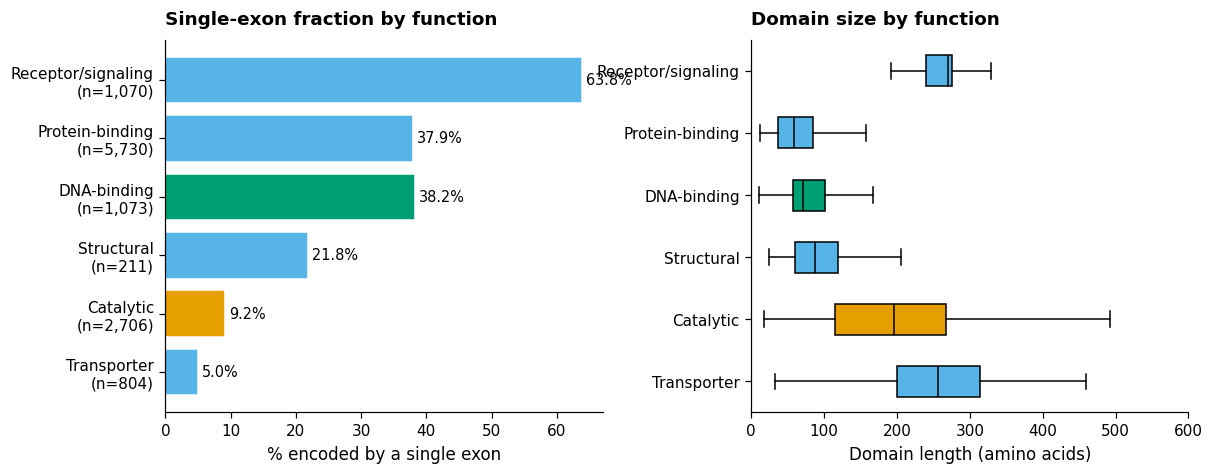

In [7]:
cs = (d[d.fclass.isin(ORDER)].groupby("fclass")
        .agg(n=("input_id", "size"),
             single=("is_single_exon_domain", lambda s: 100*s.mean()),
             med_aa=("domain_length_aa", "median"))
        .reindex(ORDER))
print(cs.round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={'wspace': 0.34})
cols = [fclass_color(f) for f in ORDER]
ax[0].barh(range(len(cs)), cs['single'], color=cols, edgecolor="white")
ax[0].set_yticks(range(len(cs)))
ax[0].set_yticklabels([f"{f}\n(n={int(n):,})" for f, n in zip(cs.index, cs.n)])
ax[0].invert_yaxis(); ax[0].grid(False)
ax[0].set_xlabel("% encoded by a single exon")
ax[0].set_title("Single-exon fraction by function", loc="left")
for i, v in enumerate(cs['single']):
    ax[0].text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=9.5)

box = [d[d.fclass == f].domain_length_aa.dropna().values for f in ORDER]
bp = ax[1].boxplot(box, vert=False, showfliers=False, patch_artist=True,
                   medianprops=dict(color="black"))
for patch, f in zip(bp['boxes'], ORDER):
    patch.set_facecolor(fclass_color(f))
ax[1].set_yticks(range(1, len(ORDER) + 1)); ax[1].set_yticklabels(ORDER)
ax[1].invert_yaxis(); ax[1].set_xlim(0, 600); ax[1].grid(False)
ax[1].set_xlabel("Domain length (amino acids)")
ax[1].set_title("Domain size by function", loc="left")
display(fig)
fig.savefig(DATA / "fig_analysis1_byclass.png", bbox_inches="tight")

## 7. Analysis #2 — where the domain sits along the protein

For each domain we take three landmarks as a fraction of the protein length:
its **start (Q1)**, **middle (Q50)** and **end (Q100)**. This is amino-acid
space, so UTRs play no part. Across the proteome, domain *starts* pile up near
the N-terminus, *ends* near the C-terminus, and *middles* sit centrally.

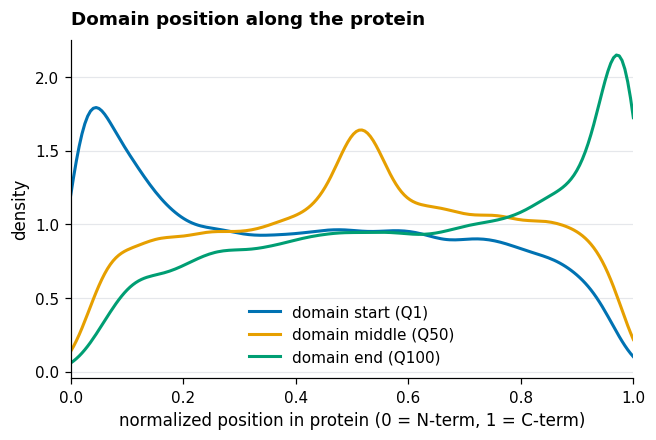

median  start 0.39  middle 0.52  end 0.66


In [8]:
fig, ax = plt.subplots(figsize=(6.6, 4))
for q, c, lab in [("pos_start", COLORS['prot2exon'], "start (Q1)"),
                  ("pos_mid",   COLORS['transvar'],  "middle (Q50)"),
                  ("pos_end",   COLORS['good'],      "end (Q100)")]:
    x, y = kde_xy(d[q])
    ax.plot(x, y, color=c, lw=2, label=f"domain {lab}")
ax.set_xlabel("normalized position in protein (0 = N-term, 1 = C-term)")
ax.set_ylabel("density"); ax.set_xlim(0, 1); ax.legend()
ax.set_title("Domain position along the protein", loc="left")
display(fig)
fig.savefig(DATA / "fig_analysis2_position.png", bbox_inches="tight")
print("median  start %.2f  middle %.2f  end %.2f"
      % (d.pos_start.median(), d.pos_mid.median(), d.pos_end.median()))

### #2 per Pfam family (top 8 by count) — start (blue) / middle (orange) / end (green)

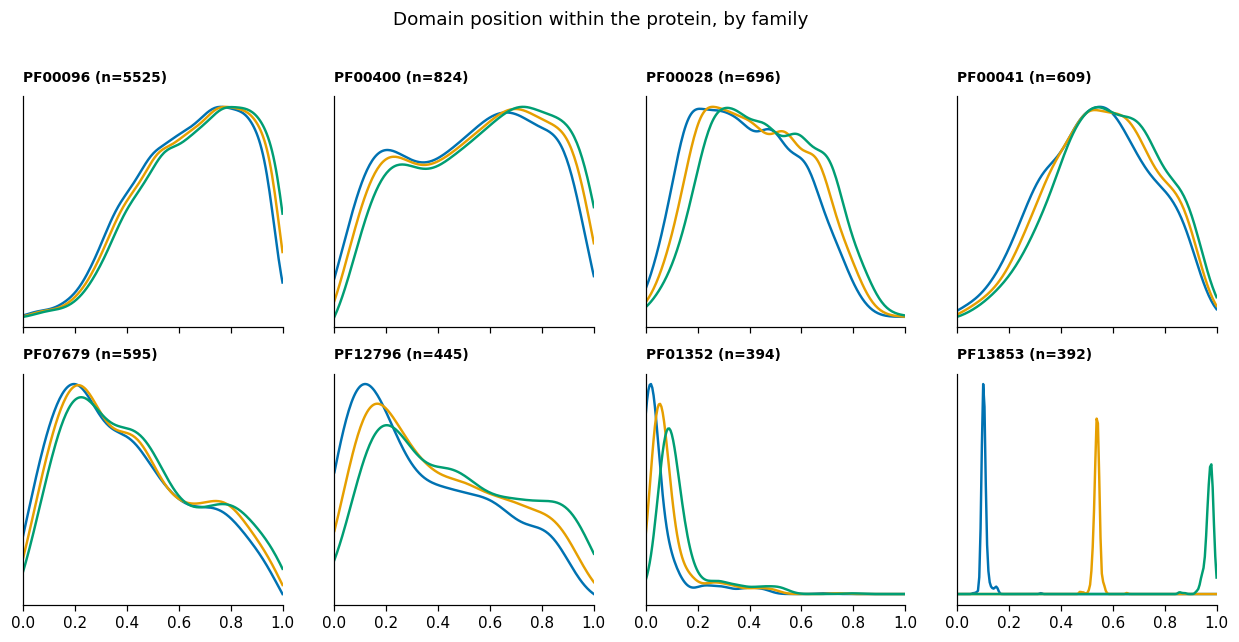

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
for axx, pf in zip(axes.ravel(), TOPFAM):
    sub = d[d.pfam_id == pf]
    for q, c in [("pos_start", COLORS['prot2exon']), ("pos_mid", COLORS['transvar']),
                 ("pos_end", COLORS['good'])]:
        x, y = kde_xy(sub[q])
        if x is not None:
            axx.plot(x, y, color=c, lw=1.6)
    axx.set_title(f"{pf} (n={len(sub)})", fontsize=9, loc="left")
    axx.set_xlim(0, 1); axx.set_yticks([])
fig.suptitle("Domain position within the protein, by family", y=1.01)
display(fig)
fig.savefig(DATA / "fig_analysis2_position_perfamily.png", bbox_inches="tight")

## 8. Analysis #3 — completeness

Completeness = domain nt ÷ nt of every exon the domain touches. Shown as a
density (single- vs multi-exon), then per Pfam family — families differ sharply
(a lone zinc finger fills ~5% of its large host exon; a fibronectin domain ~85%).

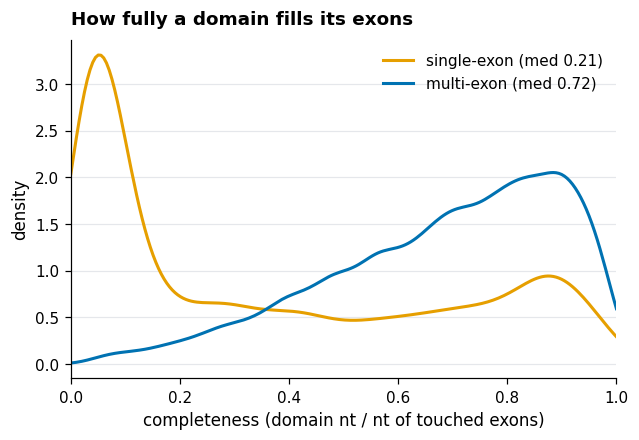

median completeness overall 0.640


In [10]:
fig, ax = plt.subplots(figsize=(6.4, 4))
for grp, c, lab in [(d[d.is_single_exon_domain], COLORS['transvar'], "single-exon"),
                    (d[~d.is_single_exon_domain], COLORS['prot2exon'], "multi-exon")]:
    x, y = kde_xy(grp.completeness)
    ax.plot(x, y, color=c, lw=2, label=f"{lab} (med {grp.completeness.median():.2f})")
ax.set_xlabel("completeness (domain nt / nt of touched exons)")
ax.set_ylabel("density"); ax.set_xlim(0, 1); ax.legend()
ax.set_title("How fully a domain fills its exons", loc="left")
display(fig)
fig.savefig(DATA / "fig_analysis3_completeness.png", bbox_inches="tight")
print(f"median completeness overall {d.completeness.median():.3f}")

### #3 per Pfam family (top 8 by count)

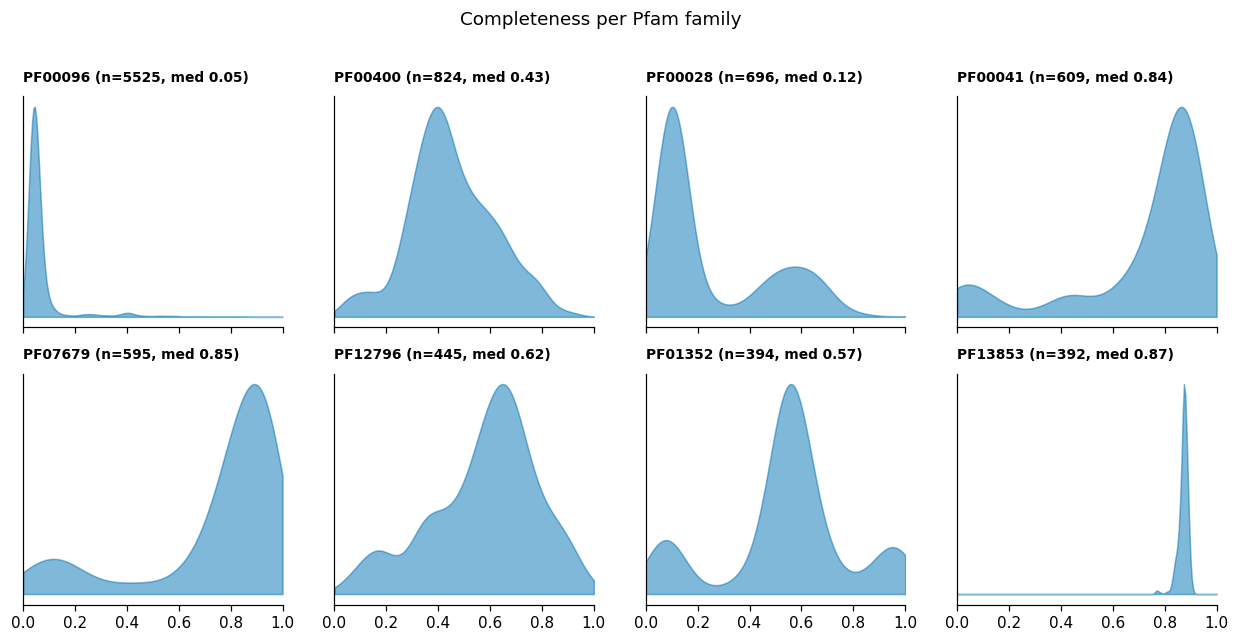

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
for axx, pf in zip(axes.ravel(), TOPFAM):
    sub = d[d.pfam_id == pf]
    x, y = kde_xy(sub.completeness)
    if x is not None:
        axx.fill_between(x, y, color=COLORS['prot2exon'], alpha=.5)
    axx.set_title(f"{pf} (n={len(sub)}, med {sub.completeness.median():.2f})",
                  fontsize=9, loc="left")
    axx.set_xlim(0, 1); axx.set_yticks([])
fig.suptitle("Completeness per Pfam family", y=1.01)
display(fig)
fig.savefig(DATA / "fig_analysis3_completeness_perfamily.png", bbox_inches="tight")

## 9. ClinVar — pathogenic variants enrich in domain-coding exons

The same atlas, used for an exon-level constraint test: are pathogenic missense
variants over-represented in CDS exons that code a Pfam-A domain? The
domain-coding interval set is the **union across all isoforms** (a variant counts
if it hits any isoform's domain exon) — the very `atlas_v115` segment table these
analyses are built on, so the two stay consistent.

In [12]:
import gzip, urllib.request, bisect
from collections import defaultdict
from scipy.stats import fisher_exact, chi2_contingency

CLINVAR_VCF = DATA / "clinvar.vcf.gz"
if not CLINVAR_VCF.exists():
    print("downloading ClinVar VCF ...")
    urllib.request.urlretrieve(
        "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz", CLINVAR_VCF)

WANT = {"Pathogenic", "Likely_pathogenic", "Benign", "Likely_benign"}
rows = []
with gzip.open(CLINVAR_VCF, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        c, p, _, ref, alt, _, _, info = line.rstrip("\n").split("\t")[:8]
        if len(ref) != 1 or len(alt) != 1:
            continue
        a = dict(x.split("=", 1) for x in info.split(";") if "=" in x)
        if a.get("MC", "").find("SO:0001583") == -1:    # missense
            continue
        if a.get("CLNSIG", "") not in WANT:
            continue
        rows.append((c, int(p), a.get("CLNSIG", ""), a.get("GENEINFO", "").split(":", 1)[0]))
cv = pd.DataFrame(rows, columns=["chrom", "pos", "clnsig", "gene"])
cv["category"] = np.where(cv.clnsig.str.contains("athog"), "pathogenic", "benign")
TOP_N = 100
top = cv.query("category=='pathogenic'").groupby("gene").size().nlargest(TOP_N).index
cvsub = cv[cv.gene.isin(top)].copy()
print(f"{len(cvsub):,} variants in top {TOP_N} genes "
      f"({(cvsub.category=='pathogenic').sum():,} path / "
      f"{(cvsub.category=='benign').sum():,} benign)")

25,453 variants in top 100 genes (20,832 path / 4,621 benign)


In [13]:
seg = pd.read_csv(ATLAS / "domain_cds_segments.tsv", sep="\t", low_memory=False,
                  usecols=["chrom", "feature_genomic_start", "feature_genomic_end",
                           "overlaps_domain"])
seg = seg.query("overlaps_domain == 'coding_overlap'").copy()
seg["chrom"] = seg.chrom.astype(str).str.removeprefix("chr")
raw = defaultdict(list)
for c, s, e in seg[["chrom", "feature_genomic_start", "feature_genomic_end"]].itertuples(index=False):
    raw[c].append((int(s), int(e)))
iv = {c: ([s for s, _ in sorted(pr)], [e for _, e in sorted(pr)]) for c, pr in raw.items()}
def in_domain(chrom, pos):
    arr = iv.get(chrom.removeprefix("chr"))
    if arr is None:
        return False
    starts, ends = arr
    i = bisect.bisect_right(starts, pos) - 1
    while i >= 0:
        if ends[i] >= pos:
            return True
        if starts[i] + 100_000 < pos:
            break
        i -= 1
    return False

cvsub["in_domain"] = [in_domain(c, p) for c, p in zip(cvsub.chrom, cvsub.pos)]
ct = (pd.crosstab(cvsub.category, cvsub.in_domain)
        .reindex(index=["benign", "pathogenic"], columns=[False, True], fill_value=0))
or_, pval = fisher_exact(ct.values, alternative="greater")
chi2 = chi2_contingency(ct.values, correction=False)[0]
p_report = "< 2.2e-16" if pval == 0.0 else f"{pval:.2e}"
print(ct)
print(f"\nodds ratio {or_:.2f}  |  Fisher's exact p {p_report}  (chi2={chi2:.0f})")

in_domain   False  True 
category                
benign       2483   2138
pathogenic   4498  16334

odds ratio 4.22  |  Fisher's exact p < 2.2e-16  (chi2=1963)


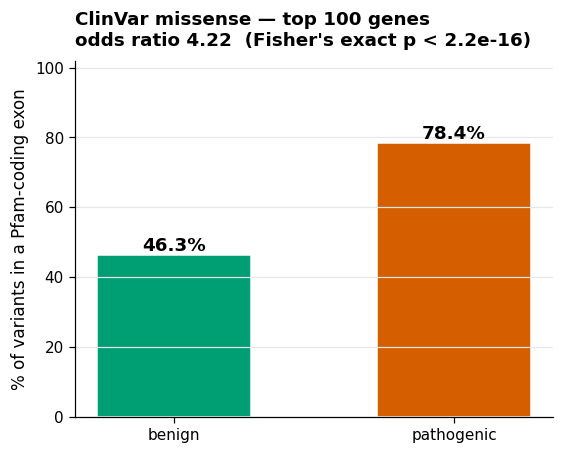

In [14]:
pct = cvsub.groupby("category")["in_domain"].mean() * 100
fig, ax = plt.subplots(figsize=(5.6, 4.2))
bars = ax.bar(["benign", "pathogenic"], [pct["benign"], pct["pathogenic"]],
              color=[COLORS['good'], COLORS['bad']], edgecolor="white", width=0.55)
for b, v in zip(bars, [pct["benign"], pct["pathogenic"]]):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.1f}%", ha="center",
            fontsize=12, fontweight="semibold")
ax.set_ylabel("% of variants in a Pfam-coding exon"); ax.set_ylim(0, max(pct) * 1.3)
ax.set_title(f"ClinVar missense — top {TOP_N} genes\n"
             f"odds ratio {or_:.2f}  (Fisher's exact p {p_report})", loc="left")
display(fig)
fig.savefig(DATA / "clinvar_enrichment.png", dpi=200, bbox_inches="tight")